# 09 — Production Workflow: Mask + Variance + XYE Export

**Time: ~25 minutes.** Builds on Notebooks 01 and 03.

## What you'll learn

This is the **production-ready integration pipeline** — the one you'd
deploy at the beamline for actual sample frames after calibration.
Three things separate "production" from "tutorial":

1. **A real bad-pixel mask** is applied (beam stop, dead pixels,
   detector module gaps). Without this, those regions corrupt the
   integrated profile and downstream peak fits.
2. **Variance is propagated** — every output bin has a 1σ uncertainty,
   so peak-fitting code can weight the data correctly and report
   meaningful confidence intervals.
3. **Output carries provenance metadata** — version, timestamp, geometry
   hash, mask fraction, source files. The output is self-describing and
   reproducible months later.

By the end you will have:

1. Auto-generated a bad-pixel mask from the Pilatus calibrant frame.
2. Built a `PolygonBinGeometry` with the mask applied (at build time —
   masked pixels never enter the integration).
3. Integrated with variance propagation, getting `(intensity, sigma)`
   per bin.
4. Written XYE (for Rietveld) and DAT (for PDF) output files with
   embedded metadata.


## Background — what each piece does

### Masks
Real detectors have:
- A **beam-stop shadow** (a small black region at the centre).
- **Dead/hot pixels** (manufacturing variation).
- **Module gaps** (e.g. Pilatus has visible dark stripes between its
  module tiles).

Including these pixels in integration adds noise (gaps) or biases
(hot pixels). The mask tells `midas-integrate-v2` which pixels to
ignore. Convention: **1.0 = masked (excluded)**.

### Variance / σ propagation
For a Poisson-statistics detector (most CCDs / pixel detectors), pixel
variance equals pixel intensity. After integration into bins, the per-bin
σ depends on:
- How many pixels contributed to the bin (more pixels ⇒ smaller σ).
- The weight of each pixel (polygon area — partial overlaps weigh less).
- The pixel variance itself (Poisson / explicit).

Standard error-propagation formula:
  σ²_bin = Σᵢ (wᵢ² σᵢ²) / (Σᵢ wᵢ)²

### Provenance metadata
Months after you generate a profile someone (or you!) will ask:
- Which version of the package made this?
- Which calibration parameters were used?
- Was a mask applied? How many pixels were masked?

`build_provenance` captures all of this in a dict that the `write_*`
helpers embed in the file header (as `# `-comments). Self-describing
files survive long after the original beamtime memory has faded.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

HERE = Path.cwd() if Path.cwd().name == "notebooks" else Path("notebooks")
REPO = HERE.resolve().parents[2]
DATA = REPO / "FF_HEDM" / "Example" / "Calibration"

from midas_integrate_v2 import (
    spec_from_v1_paramstest,
    PolygonBinGeometry, integrate_polygon_with_variance,
    mask_fraction,
    build_provenance,
    write_xye, write_dat, write_2d_csv,
)


## Step 1 — Load image + auto-build a mask

Pilatus inter-module gaps read as ~0 after dark subtraction. We
threshold on the dark-subtracted image to flag those pixels.


In [2]:
import tifffile
img_raw = tifffile.imread(
    DATA / "CeO2_Pil_100x100_att000_650mm_71p676keV_001956.tif"
).astype(np.float64)
dark = tifffile.imread(
    DATA / "dark_CeO2_Pil_100x100_att000_650mm_71p676keV_001975.tif"
).astype(np.float64)
if dark.ndim == 3:
    dark = dark.mean(axis=0)
img_clean = np.clip(img_raw - dark, 0.0, None)

# Auto-mask: pixels that read essentially zero are gaps or dead.
mask = (img_clean < 1.0).astype(np.uint8)
print(f"Image shape: {img_clean.shape}")
print(f"Masked pixels: {int(mask.sum())} ({100 * mask_fraction(mask):.1f}%)")


Image shape: (1679, 1475)
Masked pixels: 202563 (8.2%)


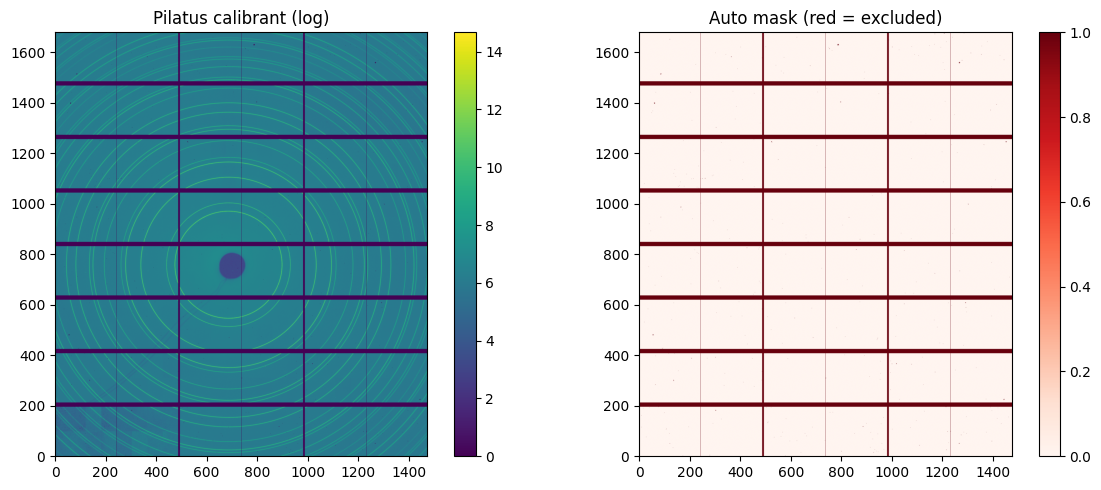

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Image (log scale)
im0 = axes[0].imshow(np.log1p(img_clean), cmap="viridis", origin="lower")
axes[0].set_title("Pilatus calibrant (log)")
fig.colorbar(im0, ax=axes[0])

# Mask
im1 = axes[1].imshow(mask, cmap="Reds", origin="lower")
axes[1].set_title("Auto mask (red = excluded)")
fig.colorbar(im1, ax=axes[1])
plt.tight_layout(); plt.show()


**You should see** the module-gap stripes show up as red bands in the
mask. This is the structure that v0.6 of the package would have
included in the integration (introducing bias and ringing); v0.7
excludes them.

## Step 2 — Build geometry with the mask + integrate with variance


In [4]:
spec = spec_from_v1_paramstest(DATA / "parameters.txt", requires_grad=False)
spec.RBinSize = 2.0
spec.EtaBinSize = 5.0

# Build polygon geometry with the mask applied at build time.
# Use n_jobs=-1 to parallelize across detector rows.
geom = PolygonBinGeometry.from_spec(spec, mask=mask, n_jobs=-1)
print(f"Polygon geometry built:")
print(f"  bins: {spec.n_eta_bins} η × {spec.n_r_bins} R = "
      f"{spec.n_eta_bins * spec.n_r_bins:,}")
print(f"  pixel-bin overlap entries: {geom.n_entries:,}")


Polygon geometry built:
  bins: 72 η × 595 R = 42,840
  pixel-bin overlap entries: 3,826,914


In [5]:
img_t = torch.from_numpy(img_clean)

# Integrate with variance propagation. Variance defaults to Poisson
# (var_pixel = max(image, 0)).
mean2d, sigma2d = integrate_polygon_with_variance(img_t, geom)
print(f"mean2d: {tuple(mean2d.shape)}")
print(f"sigma2d: {tuple(sigma2d.shape)}")


mean2d: (72, 595)
sigma2d: (72, 595)


## Step 3 — Reduce to a 1-D profile with proper σ

Per-bin η-mean of intensity is straightforward. For σ, sum the
per-η-bin variances correctly: σ²_bin_1d = (1/n_eta²) Σ_eta σ²_bin.


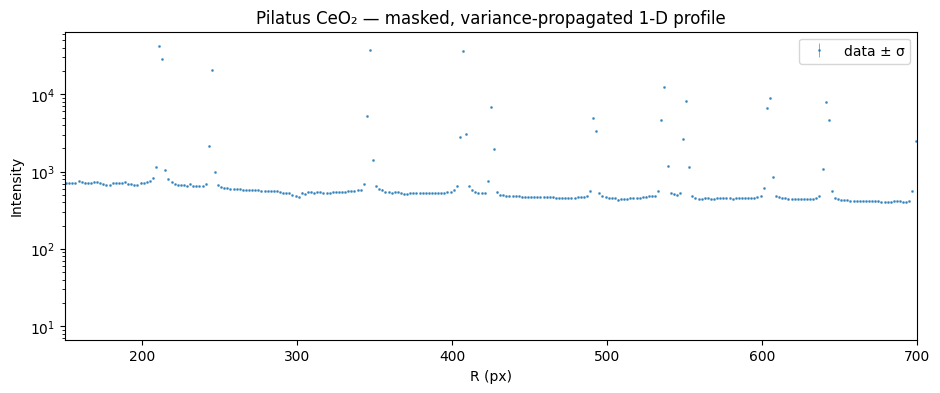

In [6]:
n_r = spec.n_r_bins
r_axis_px = spec.RMin + spec.RBinSize * (np.arange(n_r) + 0.5)

prof = mean2d.mean(dim=0).numpy()
# σ of the mean over n_eta independent η-bins
sigma_1d = ((sigma2d ** 2).sum(dim=0).sqrt() / spec.n_eta_bins).numpy()

fig, ax = plt.subplots(figsize=(11, 4))
ax.errorbar(r_axis_px, prof, yerr=sigma_1d, fmt=".", ms=2, lw=0.5,
            ecolor="red", alpha=0.7, label="data ± σ")
ax.set_xlabel("R (px)"); ax.set_ylabel("Intensity")
ax.set_yscale("log"); ax.set_xlim(150, 700)
ax.set_title("Pilatus CeO₂ — masked, variance-propagated 1-D profile")
ax.legend(); plt.show()


**Notice the error bars.** Bins that received few pixels (out near
the edge of the binned R range, or near the masked module gaps) have
larger σ than bins in the middle of well-sampled rings. A downstream
peak-fit weighting by `1/σ²` would correctly down-weight noisy bins.

## Step 4 — Build provenance metadata

Capture everything needed to reconstruct the calculation later.


In [7]:
md = build_provenance(
    spec,
    integrate_mode="polygon",
    extra={
        "image_file":      str((DATA / "CeO2_Pil_100x100_att000_650mm_71p676keV_001956.tif").name),
        "dark_file":       str((DATA / "dark_CeO2_Pil_100x100_att000_650mm_71p676keV_001975.tif").name),
        "mask_method":     "intensity < 1.0 after dark subtraction",
        "masked_fraction": mask_fraction(mask),
    },
)

import json
print(json.dumps(md.to_header_lines(""), indent=2))


[
  "{",
  "  \"package\": \"midas_integrate_v2\",",
  "  \"version\": \"0.6.0\",",
  "  \"timestamp_iso\": \"2026-05-10T02:07:49.525118+00:00\",",
  "  \"integrate_mode\": \"polygon\",",
  "  \"n_r_bins\": 595,",
  "  \"n_eta_bins\": 72,",
  "  \"spec_summary\": {",
  "    \"Lsd_um\": 657436.895687981,",
  "    \"BC_y_px\": 685.485459654125,",
  "    \"BC_z_px\": 921.034377043941,",
  "    \"tx_deg\": 0.0,",
  "    \"ty_deg\": 0.200888234849,",
  "    \"tz_deg\": 0.44690237631,",
  "    \"Parallax_um\": 0.0,",
  "    \"Wavelength_A\": 0.172973,",
  "    \"pxY_um\": 172.0,",
  "    \"pxZ_um\": 172.0,",
  "    \"NrPixelsY\": 1475,",
  "    \"NrPixelsZ\": 1679,",
  "    \"RhoD_px\": 219964.42411013643,",
  "    \"RBinSize_px\": 2.0,",
  "    \"EtaBinSize_deg\": 5.0,",
  "    \"TransOpt\": [",
  "      2",
  "    ],",
  "    \"spec_hash\": \"2d32b82b3e0a2023\"",
  "  },",
  "  \"extra\": {",
  "    \"image_file\": \"CeO2_Pil_100x100_att000_650mm_71p676keV_001956.tif\",",
  "    \"dark_fil

## Step 5 — Write XYE for Rietveld + DAT for PDF

Two common downstream formats. Both carry the metadata above as a
`# `-prefixed JSON header.


In [8]:
out_dir = HERE / "v07_demo_outputs"
out_dir.mkdir(exist_ok=True, parents=True)

# Convert R (px) → 2θ (centidegrees) for the GSAS XYE convention
two_theta_deg = np.degrees(np.arctan(r_axis_px * spec.pxY / float(spec.Lsd)))
two_theta_centidegrees = two_theta_deg * 100.0

# XYE: 2θ in centidegrees + intensity + σ
xye_path = out_dir / "ceo2.xye"
write_xye(xye_path,
          r_axis=two_theta_centidegrees,
          intensity=prof, sigma=sigma_1d,
          metadata=md)
print(f"wrote {xye_path}")

# Convert R (px) → Q (Å⁻¹) for the PDF .dat convention
two_theta_rad = np.arctan(r_axis_px * spec.pxY / float(spec.Lsd))
Q_invA = (4 * np.pi / float(spec.Wavelength)) * np.sin(two_theta_rad / 2.0)

dat_path = out_dir / "ceo2.dat"
write_dat(dat_path, q_axis_invA=Q_invA, intensity=prof,
          sigma=sigma_1d, metadata=md)
print(f"wrote {dat_path}")


wrote /Users/hsharma/opt/MIDAS/packages/midas_integrate_v2/notebooks/v07_demo_outputs/ceo2.xye
wrote /Users/hsharma/opt/MIDAS/packages/midas_integrate_v2/notebooks/v07_demo_outputs/ceo2.dat


In [9]:
# Show the XYE file's header so you can see the embedded provenance
with open(xye_path) as f:
    head = []
    for line in f:
        if line.startswith("#") or "BANK" in line:
            head.append(line.rstrip())
        else:
            break
print("\n".join(head[:25]))


# {
#   "package": "midas_integrate_v2",
#   "version": "0.6.0",
#   "timestamp_iso": "2026-05-10T02:07:49.525118+00:00",
#   "integrate_mode": "polygon",
#   "n_r_bins": 595,
#   "n_eta_bins": 72,
#   "spec_summary": {
#     "Lsd_um": 657436.895687981,
#     "BC_y_px": 685.485459654125,
#     "BC_z_px": 921.034377043941,
#     "tx_deg": 0.0,
#     "ty_deg": 0.200888234849,
#     "tz_deg": 0.44690237631,
#     "Parallax_um": 0.0,
#     "Wavelength_A": 0.172973,
#     "pxY_um": 172.0,
#     "pxZ_um": 172.0,
#     "NrPixelsY": 1475,
#     "NrPixelsZ": 1679,
#     "RhoD_px": 219964.42411013643,
#     "RBinSize_px": 2.0,
#     "EtaBinSize_deg": 5.0,
#     "TransOpt": [
#       2


**That's a fully self-describing output.** Six months from now:

- The package version is in the file ⇒ if v2.x.y produced different
  numerics, you know which version's behaviour to expect.
- The geometry hash is in the file ⇒ you can recreate the exact spec.
- The image / dark file names are in the file ⇒ you know what raw
  data went in.
- The mask method + masked fraction are in the file ⇒ you know what
  was excluded.

## Step 6 — Optional: write the 2-D integrated array

For texture / single-grain analysis you often want the full
`(η, R)` array, not just the η-collapsed 1-D.


In [10]:
eta_axis = spec.EtaMin + spec.EtaBinSize * (np.arange(spec.n_eta_bins) + 0.5)

write_2d_csv(out_dir / "ceo2_2d.csv",
             int2d=mean2d.numpy(),
             r_axis_px=r_axis_px,
             eta_axis_deg=eta_axis,
             metadata=md)
print(f"wrote {out_dir / 'ceo2_2d.csv'}")


wrote /Users/hsharma/opt/MIDAS/packages/midas_integrate_v2/notebooks/v07_demo_outputs/ceo2_2d.csv


## Production-grade integration pipeline summary

```
calibrant frame ─┐
dark frame ──────┼─→ load + dark-subtract ──┐
                 │                          │
                 └─→ auto-mask (gaps)       │
                                            ▼
                                  PolygonBinGeometry(mask, n_jobs=-1)
                                            │
                                            ▼
                                  integrate_polygon_with_variance
                                            │
                                            ▼
                            (mean, σ) per bin in 2-D and 1-D
                                            │
                                            ▼
                       build_provenance + write_xye / write_dat / write_2d_csv
                                            │
                                            ▼
                              self-describing output files
```

That's a complete production pipeline in <30 lines of code.

## Try it yourself

1. **Add a beamstop mask.** The auto-mask doesn't catch the small
   beam-stop shadow at the centre because that region's intensity is
   nonzero (scattered light). Add a circular mask of radius 30 px
   around BC and confirm the inner R-bins now have NaN intensity
   (no contributing pixels).

2. **Compare with vs without mask.** Integrate the same image with
   `mask=None` vs the auto-mask. Plot the two profiles together —
   the masked version should be smoother, with no spurious peaks at
   R values corresponding to the module-gap rings.

3. **Read the XYE back into a Rietveld tool.** Open the file in
   GSAS-II / FullProf / Topas / Jana — they should parse the FXYE
   header and ignore the `#` comment block.

4. **Re-construct from provenance.** Read just the JSON header from
   `ceo2.xye`, parse `spec_summary`, and rebuild the `IntegrationSpec`
   from those values. Confirm the new spec's `_spec_param_hash`
   matches the embedded one.

## You're (really) done

Through these 9 notebooks you've covered the full HEDM detector
calibration + integration + downstream PDF/Rietveld pipeline:

- 01: First integration (just enough to see rings)
- 02: Geometry intuition (what each parameter does)
- 03: Joint refinement (the v2 headline)
- 04: Multi-distance calibration
- 05: calibrate-v2 ↔ integrate-v2 handoff
- 06: Custom losses (writing your own)
- 07: Bayesian uncertainty quantification
- 08: PDF analysis (R → Q → G(r))
- 09: Production pipeline (mask, variance, provenance, XYE/DAT)

You have everything needed to take a calibrant frame from a beamline,
calibrate it, integrate sample frames against the calibration, and
emit downstream-tool-ready outputs with proper uncertainties.

For the C+CUDA legacy MIDAS pipeline, the `midas-integrate` v0.4.0+
docs cover it. For the broader MIDAS ecosystem (peak fitting,
indexing, grain mapping), see the relevant `midas-*` packages.
